In [6]:
# SU SOLUCIÓN REFACTORIZADA — Práctica S1, Actividad 2
from dataclasses import dataclass


@dataclass
class Nota:
    curso: str
    calificacion: float


class Estudiante:
    def __init__(self, nombre: str, codigo: int, escuela: str):
        self._nombre = nombre
        self._codigo = codigo
        self._escuela = escuela
        self._historial_notas: list[Nota] = []

    @property
    def nombre(self) -> str:
        return self._nombre

    def agregar_nota(self, curso: str, calificacion: float) -> None:
        if not (0 <= calificacion <= 20):
            raise ValueError(f"La calificación debe estar en el rango [0, 20]. Valor recibido: {calificacion}")

        self._historial_notas.append(Nota(curso, calificacion))

    def calcular_ppa(self) -> float:
        if not self._historial_notas:
            return 0.0

        suma_calificaciones = sum(nota.calificacion for nota in self._historial_notas)
        return suma_calificaciones / len(self._historial_notas)

    def __str__(self) -> str:
        lineas = [
            f"Estudiante: {self._nombre} | Código: {self._codigo} | Escuela: {self._escuela}",
            "Notas:"
        ]
        for nota in self._historial_notas:
            lineas.append(f"  - {nota.curso}: {nota.calificacion}")
        return "\n".join(lineas)


# Prueba — debe ejecutar sin errores:
if __name__ == "__main__":
    e = Estudiante("Juan Carlos Mamani Quispe", 20210500, "Ing. Sistemas")
    e.agregar_nota("POO II", 16)
    e.agregar_nota("Base de Datos I", 14)
    print(e)
    print(f"PPA: {e.calcular_ppa():.2f}")

    try:
        e.agregar_nota("Redes", 25) # debe lanzar ValueError
    except ValueError as ex:
        print(f"Error capturado correctamente: {ex}")

Estudiante: Juan Carlos Mamani Quispe | Código: 20210500 | Escuela: Ing. Sistemas
Notas:
  - POO II: 16
  - Base de Datos I: 14
PPA: 15.00
Error capturado correctamente: La calificación debe estar en el rango [0, 20]. Valor recibido: 25


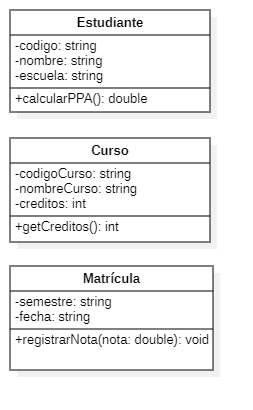